In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print('库导入完成！')

库导入完成！


In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(f'训练集大小: {train.shape}')
print(f'测试集大小: {test.shape}')
train.head()

训练集大小: (1460, 81)
测试集大小: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


=== 目标变量 SalePrice 分布 ===
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


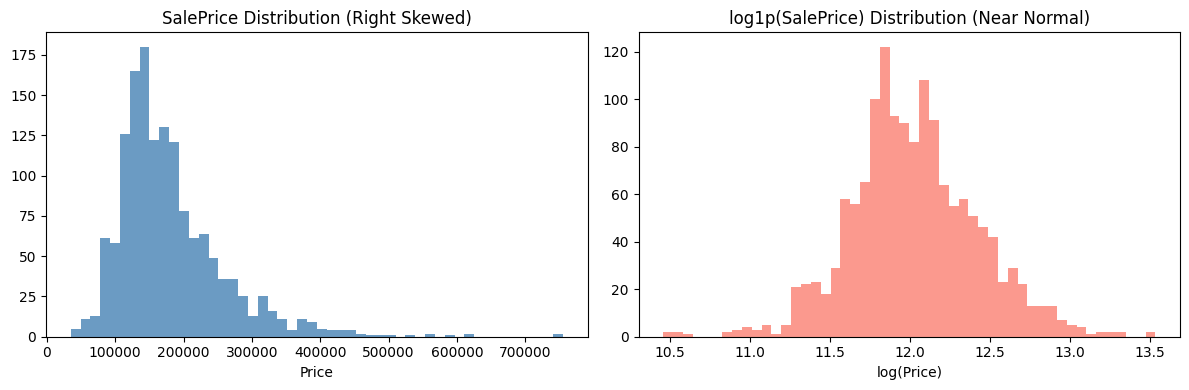

→ 对SalePrice做log1p变换可以改善模型效果


In [3]:
print('=== 目标变量 SalePrice 分布 ===')
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 原始分布
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('SalePrice Distribution (Right Skewed)')
axes[0].set_xlabel('Price')

# log变换后分布
axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='salmon', alpha=0.8)
axes[1].set_title('log1p(SalePrice) Distribution (Near Normal)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 对SalePrice做log1p变换可以改善模型效果')

训练集有缺失值的特征数：19


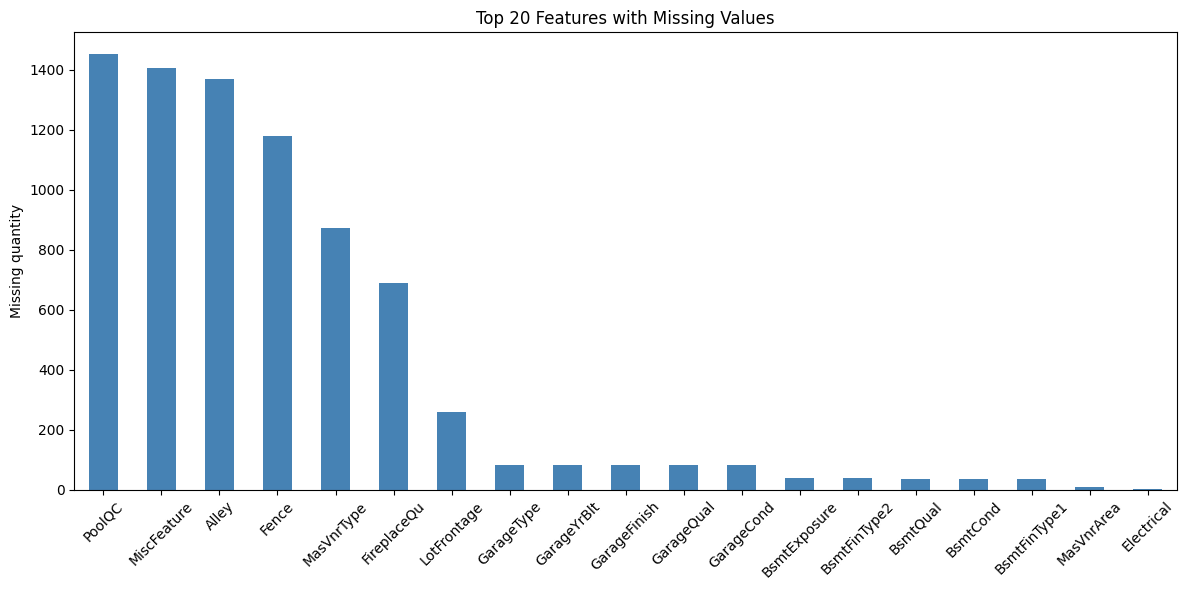

In [4]:
# 缺失值分析
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'训练集有缺失值的特征数：{len(missing)}')

plt.figure(figsize=(12, 6))
missing.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Features with Missing Values')
plt.ylabel('Missing quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

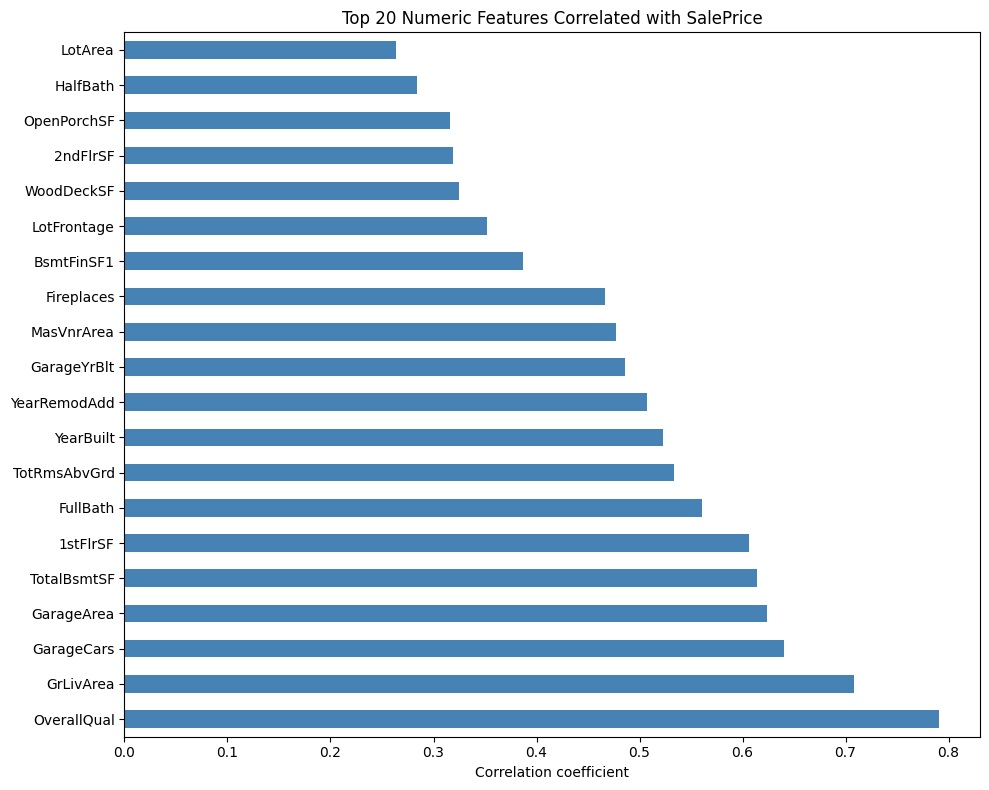

相关性TOP10：
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [5]:
# 数值特征与SalePrice的相关性
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Numeric Features Correlated with SalePrice')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('相关性TOP10：')
print(corr.head(10))

In [6]:
# 目标变量做log1p变换
y_train = np.log1p(train['SalePrice'])

# 合并训练集和测试集一起处理
combined = pd.concat([train.drop('SalePrice', axis=1), test], axis=0).reset_index(drop=True)
print(f'合并后数据大小: {combined.shape}')

# 分类特征：缺失值填充为'None'（表示没有该设施）
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'MSSubClass'
]
for col in cat_none_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna('None')

# 数值特征：缺失值填充为0（表示没有该设施面积等）
num_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# 其余分类特征用众数填充
cat_cols = combined.select_dtypes(include=['object']).columns
for col in cat_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

# 其余数值特征用中位数填充
num_cols = combined.select_dtypes(include=[np.number]).columns
for col in num_cols:
    combined[col] = combined[col].fillna(combined[col].median())

print(f'处理后缺失值总数: {combined.isnull().sum().sum()}')
print('数据清洗完成！')

合并后数据大小: (2919, 80)
处理后缺失值总数: 0
数据清洗完成！


In [7]:
# 1. 总面积（重要的衍生特征）
combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']

# 2. 房屋年龄
combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']

# 3. 是否翻修过
combined['IsRemodeled'] = (combined['YearBuilt'] != combined['YearRemodAdd']).astype(int)

# 4. 总浴室数
combined['TotalBath'] = (combined['FullBath'] + 0.5 * combined['HalfBath'] +
                         combined['BsmtFullBath'] + 0.5 * combined['BsmtHalfBath'])

# 5. 是否有车库/地下室/泳池
combined['HasGarage'] = (combined['GarageArea'] > 0).astype(int)
combined['HasBasement'] = (combined['TotalBsmtSF'] > 0).astype(int)
combined['HasPool'] = (combined['PoolArea'] > 0).astype(int)

print('特征工程完成！新增特征：TotalSF, HouseAge, RemodAge, IsRemodeled, TotalBath, HasGarage, HasBasement, HasPool')

特征工程完成！新增特征：TotalSF, HouseAge, RemodAge, IsRemodeled, TotalBath, HasGarage, HasBasement, HasPool


In [8]:
# 对分类特征进行Label Encoding
cat_cols = combined.select_dtypes(include=['object']).columns
print(f'需要编码的分类特征数：{len(cat_cols)}')

le = LabelEncoder()
for col in cat_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# 删除无用的ID列
combined = combined.drop(['Id'], axis=1, errors='ignore')

# 分回训练集和测试集
X_train = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

print(f'训练集特征维度: {X_train.shape}')
print(f'测试集特征维度: {X_test.shape}')
print('编码完成！')

需要编码的分类特征数：43
训练集特征维度: (1460, 87)
测试集特征维度: (1459, 87)
编码完成！


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def rmse_cv(model, X, y, n_folds=5):
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf))
    return rmse

models = {
    'Linear Regression': LinearRegression(),
    'Lasso regression': Lasso(alpha=0.0005, random_state=42),
    'Ridge regression': Ridge(alpha=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    'GBDT': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
}

results = {}
print('=== 5折交叉验证RMSE（越低越好）===')
for name, model in models.items():
    scores = rmse_cv(model, X_train_scaled, y_train)
    results[name] = scores
    print(f'{name}: 均值={scores.mean():.4f}, 标准差={scores.std():.4f}')

=== 5折交叉验证RMSE（越低越好）===
Linear Regression: 均值=0.1616, 标准差=0.0418
Lasso regression: 均值=0.1581, 标准差=0.0481
Ridge regression: 均值=0.1584, 标准差=0.0468
Random Forest: 均值=0.1417, 标准差=0.0186
GBDT: 均值=0.1329, 标准差=0.0197


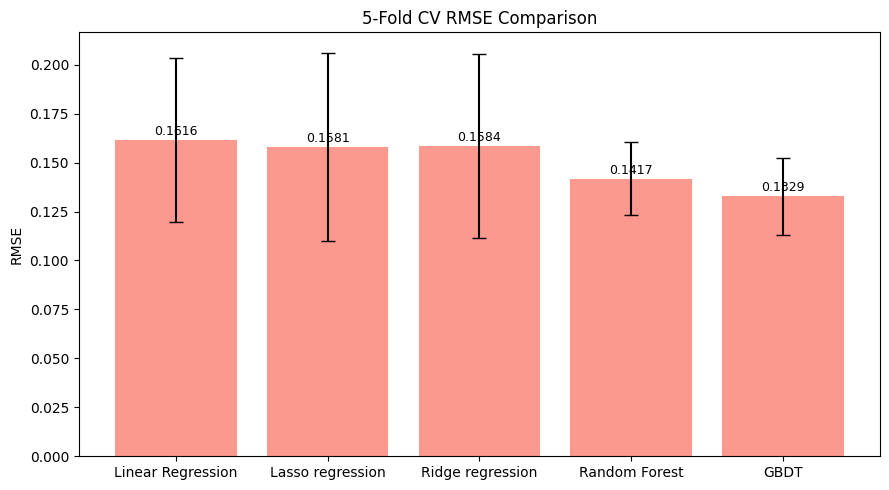

最优模型: GBDT (RMSE=0.1329)


In [10]:
# 可视化模型对比
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds = [results[m].std() for m in model_names]

bars = ax.bar(model_names, means, yerr=stds, capsize=5, color='salmon', alpha=0.8)
ax.set_ylabel('RMSE')
ax.set_title('5-Fold CV RMSE Comparison')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = min(results, key=lambda x: results[x].mean())
print(f'最优模型: {best_model_name} (RMSE={results[best_model_name].mean():.4f})')

In [11]:
# 用最优模型训练全量数据并预测
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
predictions_log = best_model.predict(X_test_scaled)

# 还原log变换（expm1是log1p的逆变换）
predictions = np.expm1(predictions_log)

# 生成提交文件
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predictions
})
submission.to_csv('submission.csv', index=False)

print('提交文件生成完成：submission.csv')
print(f'预测价格分布：')
print(submission['SalePrice'].describe())
submission.head()

提交文件生成完成：submission.csv
预测价格分布：
count      1459.000000
mean     177743.746702
std       76832.284786
min       41449.470374
25%      127620.984286
50%      157536.592657
75%      206160.096974
max      587280.091152
Name: SalePrice, dtype: float64


,Id,SalePrice
0,1461,124705.642048
1,1462,170643.371282
2,1463,179213.491987
3,1464,186611.201798
4,1465,184995.043619


In [12]:
print('=== 项目总结 ===')
print(f'数据集：训练集{len(train)}条，测试集{len(test)}条')
print(f'特征数量：{X_train.shape[1]}个（含8个衍生特征）')
print('\n模型交叉验证结果（RMSE）：')
for name in model_names:
    print(f'  {name}: {results[name].mean():.4f} ± {results[name].std():.4f}')
print(f'\n最终选用模型：{best_model_name}')

=== 项目总结 ===
数据集：训练集1460条，测试集1459条
特征数量：87个（含8个衍生特征）

模型交叉验证结果（RMSE）：
  Linear Regression: 0.1616 ± 0.0418
  Lasso regression: 0.1581 ± 0.0481
  Ridge regression: 0.1584 ± 0.0468
  Random Forest: 0.1417 ± 0.0186
  GBDT: 0.1329 ± 0.0197

最终选用模型：GBDT
